In [1]:
import sys
sys.path.insert(0,'/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/')

In [10]:
import os

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [3]:
data = Table.read('/home/emaragliano/myfarm-disk/QuijoteSimulations/QuijoteHalos_RSD/groups_002/000/Quijote_2_id_0_RSD.fits')

In [4]:
idxs = np.random.choice(len(data), size=len(data)//10, replace=False)

In [5]:
#compute comoving distance to z=1
from astropy.cosmology import Planck18 as cosmo
z = 1.0
comoving_distance = cosmo.comoving_distance(z).value  # in Mpc
print(f"Comoving distance to z={z}: {comoving_distance:.2f} Mpc")


Comoving distance to z=1.0: 3395.63 Mpc


In [6]:
data_pos = np.array([data[idxs]['X'], data[idxs]['Y'], comoving_distance+data[idxs]['Z']]).T

print('data pos min', data_pos.min())
print('data pos max', data_pos.max())

len(data_pos)
NRANDOM = 30*len(data_pos)
random_pos = np.random.uniform(0, 1000, size=(NRANDOM, 3))
random_pos[:, 2] += comoving_distance

data pos min 0.0015308686
data pos max 4395.6294


# Rec params

In [7]:
COMPARE_AGAINST_PYRECON = 'iFFT'  # 'iFFT' or 'MG'

In [8]:
BIAS = 1.7
GROWTH_RATE = 0.88
RSD_SPACE = 'redshift_space'  # 'real_space' or 'redshift_space'

NMESH = 256                     # 256, 512, 1024
RAND_TH = 0.01

LOS = None                      # None, 'x', 'y', 'z' 
SM_RAD = 15.0                   # 5, 7.5, 10, 12.5, 15, 20

PBC = True                      # True, False
MAS = 'TSC'                     # 'CIC', 'TSC'

PAD = 0.0 if PBC else 100.0     # 1, 10, 30, 100, 300
OUTDIR = f'outputs/{RSD_SPACE}/bias_{BIAS}_f_{GROWTH_RATE}_{NMESH}_randth{RAND_TH}_los_{LOS}_sm{SM_RAD}_pad{PAD}_{MAS}_pbc{PBC}'


In [11]:
os.makedirs(OUTDIR, exist_ok=True)

Saving outputs

In [12]:
import os
import yaml
from scipy.stats import ks_2samp

def compute_and_save_ks(psi_mg, psi_pyrecon, mag_mg, mag_pyrecon, results_dict, outdir, key_name='ks_psi_rsd'):
    """
    Calcola le statistiche di Kolmogorov-Smirnov, aggiorna il dizionario 
    usando una chiave personalizzabile e salva in YAML.
    
    Parametri:
    - ... (gli stessi di prima) ...
    - key_name: Stringa, il nome del sottomenu nel dizionario (default: 'ks_psi_rsd').
    """
    ks_results = {}
    
    # 1. Calcolo test KS sulle componenti
    for i, comp in enumerate(['X', 'Y', 'Z']):
        ks_stat, ks_pvalue = ks_2samp(psi_mg[..., i].flatten(), psi_pyrecon[..., i].flatten())
        ks_results[f'ks_{comp}'] = {'statistic': float(ks_stat), 'pvalue': float(ks_pvalue)}
        
    # 2. Calcolo test KS sulla magnitudo
    ks_stat_mag, ks_pvalue_mag = ks_2samp(mag_mg.flatten(), mag_pyrecon.flatten())
    ks_results['ks_magnitude'] = {'statistic': float(ks_stat_mag), 'pvalue': float(ks_pvalue_mag)}
    
    # 3. Stampa dinamica basata sul nome della chiave
    print(f"--- KS test results for: {key_name} ---")
    for comp in ['X', 'Y', 'Z']:
        print(f"  {comp}: statistic={ks_results[f'ks_{comp}']['statistic']:.4f}, p-value={ks_results[f'ks_{comp}']['pvalue']:.4e}")
    print(f"  Magnitude: statistic={ks_stat_mag:.4f}, p-value={ks_pvalue_mag:.4e}\n")

    # 4. Aggiornamento del sottomenu specificato
    if key_name not in results_dict:
        results_dict[key_name] = {}  
        
    for comp in ['X', 'Y', 'Z']:
        results_dict[key_name][f'ks_{comp}'] = ks_results[f'ks_{comp}']['statistic']
        results_dict[key_name][f'ks_{comp}_pvalue'] = ks_results[f'ks_{comp}']['pvalue']
        
    results_dict[key_name]['ks_magnitude'] = ks_results['ks_magnitude']['statistic']
    results_dict[key_name]['ks_magnitude_pvalue'] = ks_results['ks_magnitude']['pvalue']
    
    # 5. Salvataggio
    os.makedirs(outdir, exist_ok=True)
    with open(os.path.join(outdir, "results.yaml"), "w") as f:
        yaml.dump(results_dict, f)
        
    return results_dict

# Zelda FFT

In [13]:
from zeldareco.BAOreconstruction.bao_ifft import BAOiFFTreconstruction

/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [14]:
recon = BAOiFFTreconstruction(
    data_pos=data_pos, 
    random_pos=random_pos,
    #boxsize=BOX_SIZE,    
    RSDspace = RSD_SPACE,
    nmesh = NMESH,
    #boxcentre=np.array(BOX_CENTER),
    los = LOS,
    f = GROWTH_RATE,
    bias = BIAS,
    R_sm = SM_RAD,
    threshold_randoms = RAND_TH,
    padding = PAD,
    pbc = PBC,
    MAS = MAS
)

2026-05-20 14:42:47,515 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - mean data pos: [ 500.13785  501.32397 3894.0574 ]
2026-05-20 14:42:47,590 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - mean random pos: [ 499.96710277  499.94613072 3895.73976827]
2026-05-20 14:42:47,941 - zeldareco.utils.formatters - INFO - Rectangular box not yet supported. Setting box size to [999.9999, 999.9999, 999.9999] based on maximum separation in positions with padding 0.0.
2026-05-20 14:42:47,942 - zeldareco.BAOreconstruction.density_manager - INFO - Box size not provided. Set to [999.9999 999.9999 999.9999] based on positions with padding 0.0.
2026-05-20 14:42:48,249 - zeldareco.utils.formatters - INFO - Setting box centre to [ 499.99993608  500.00008154 3895.63450565] from position range
2026-05-20 14:42:48,250 - zeldareco.BAOreconstruction.density_manager - INFO - Box centre not provided. Set to [ 499.99994  500.0001  3895.6345 ] based on positions.
2026-05-20 14:42:48,442 - zelda

In [15]:
recon.print_info()

2026-05-20 14:42:50,630 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - ============================================================
2026-05-20 14:42:50,631 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - BAO Reconstruction (IFFT) Information:
2026-05-20 14:42:50,631 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - ============================================================
2026-05-20 14:42:50,632 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Mesh: 256^3 points
2026-05-20 14:42:50,632 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Box size: 999.9998779296875 Mpc/h
2026-05-20 14:42:50,633 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Box centre: [ 499.99994  500.0001  3895.6345 ]
2026-05-20 14:42:50,633 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Padding: 0.0 Mpc/h
2026-05-20 14:42:50,633 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Cell size: 3.9062 Mpc/h
2026-05-20 14:42:50,634 - zeldareco.BAOreconstru

check the overdensity field

In [16]:
delta_mg = recon.compute_delta_mesh()

/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/zeldareco/mesh/mesh.py:37: UserWarning: cell_size is not an integer number.
  warnings.warn("cell_size is not an integer number.", UserWarning)
2026-05-20 14:43:00,838 - zeldareco.mass_assignment - INFO - Using single-threaded TSC interpolation.

2026-05-20 14:43:03,143 - zeldareco.mass_assignment - INFO - Using single-threaded TSC interpolation.



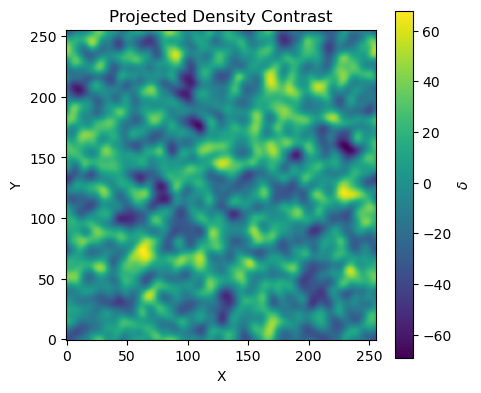

In [17]:
plt.figure(figsize=(5,4.5))
plt.imshow(delta_mg.sum(axis=2).T, origin='lower',  cmap='viridis')
plt.colorbar(label='$\\delta$')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Projected Density Contrast')
plt.show()

check the solver behaviour

In [18]:
phi_mesh_ifft = recon.solver.potential

In [19]:
psi_mesh_ifft = recon.solver.displacement

overplot potential, displacement and density field

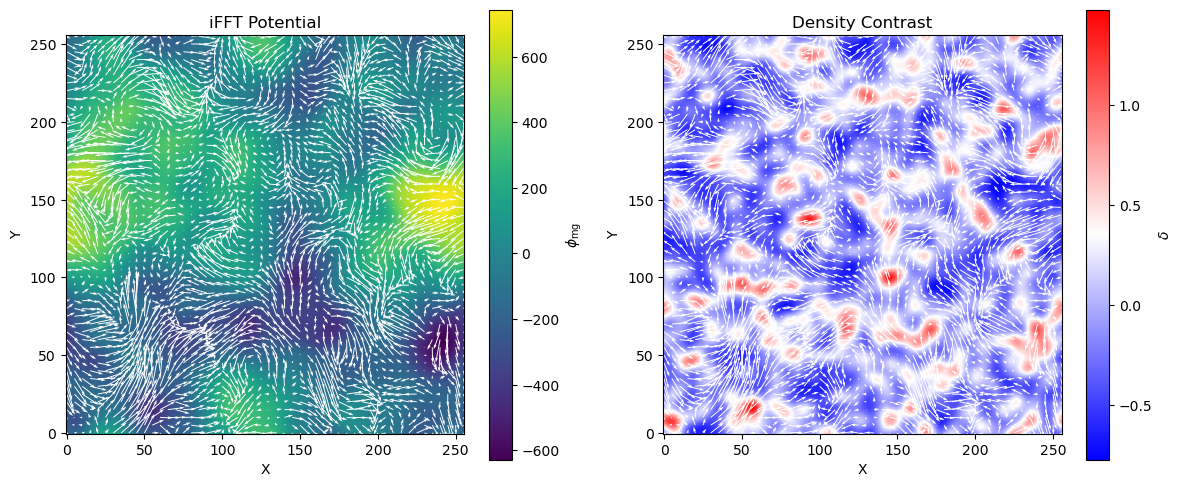

In [21]:
from matplotlib.colors import TwoSlopeNorm

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

#norm = TwoSlopeNorm(vmin=delta_mg.min(), vcenter=0, vmax=delta_mg.max())

slice = NMESH//2
im1 = axs[0].imshow(phi_mesh_ifft[slice].T, origin='lower', cmap='viridis')
axs[0].set_title('iFFT Potential')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
fig.colorbar(im1, ax=axs[0], label='$\\phi_\mathrm{mg}$')


im2 = axs[1].imshow(delta_mg[slice].T, origin='lower', cmap='bwr')#'bwr, norm=norm)
axs[1].set_title('Density Contrast')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
fig.colorbar(im2, ax=axs[1], label='$\\delta$')

#overplot quiver displacement field
step = 5
X, Y = np.meshgrid(np.arange(0, NMESH, step), np.arange(0, NMESH, step))
U = psi_mesh_ifft[0][::step, ::step, 0].T
V = psi_mesh_ifft[0][::step, ::step, 1].T
axs[0].quiver(X, Y, U, V, color='white', scale=100)
axs[1].quiver(X, Y, U, V, color='white', scale=100)

plt.tight_layout()
plt.savefig(f'{OUTDIR}/potential_density_quiver.png', dpi=300)
plt.show()

Plot histo of the displacement on mesh

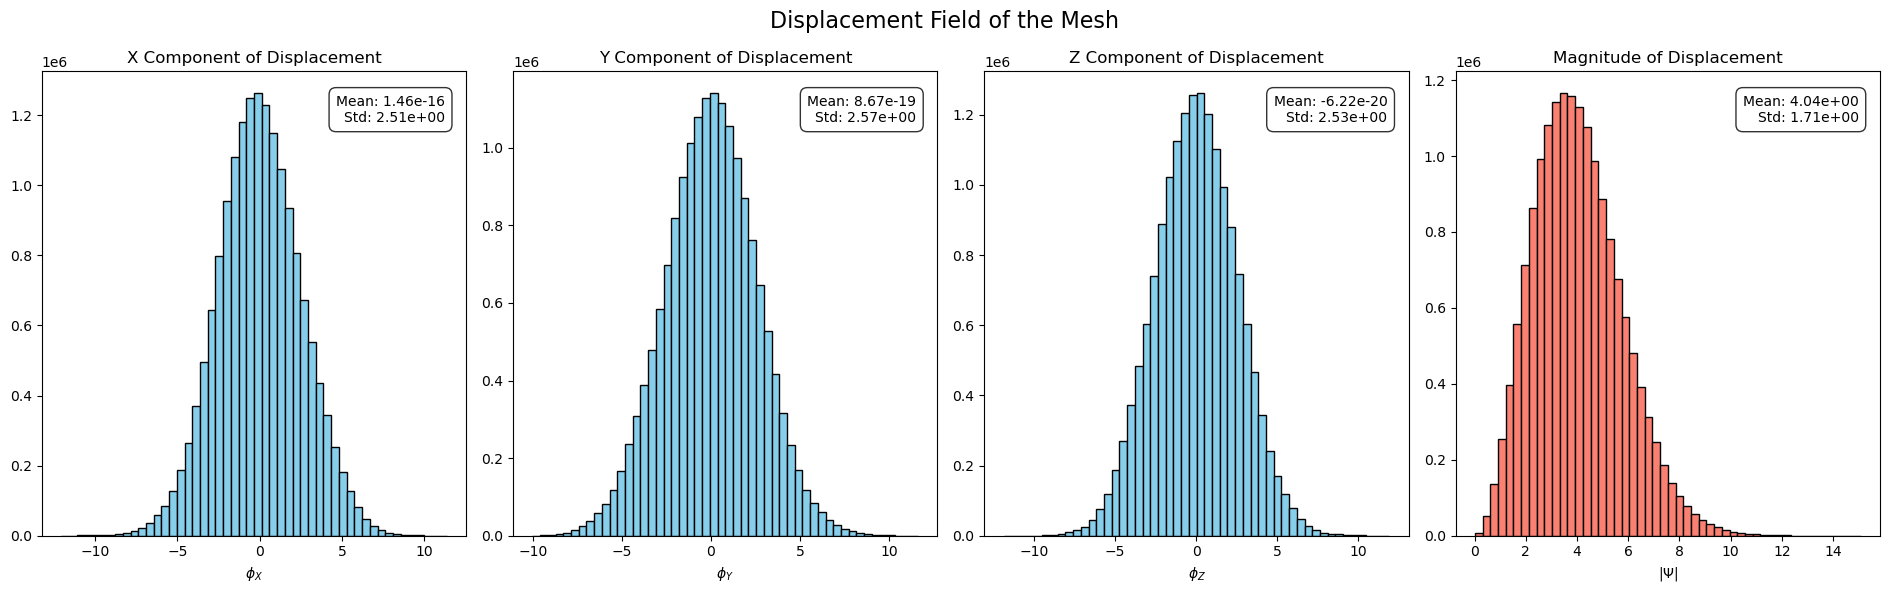

In [22]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(19, 6))

for i, comp in enumerate(['X', 'Y', 'Z']):
    axs[i].set_title(f'{comp} Component of Displacement')
    # Use index i on the last axis and flatten for the histogram
    axs[i].hist(psi_mesh_ifft[..., i].flatten(), bins=50, color='skyblue', edgecolor='black')
    axs[i].set_xlabel(f'$\\phi_{comp}$')
    axs[i].text(0.95, 0.95, f'Mean: {psi_mesh_ifft[..., i].mean():.2e}\nStd: {psi_mesh_ifft[..., i].std():.2e}',
            transform=axs[i].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))


# Calculate magnitude across the last axis (the 3 components)
axs[3].set_title('Magnitude of Displacement')
psi_magnitude = np.linalg.norm(psi_mesh_ifft, axis=-1) 
axs[3].hist(psi_magnitude.flatten(), bins=50, color='salmon', edgecolor='black')
axs[3].set_xlabel('$|\Psi|$')
axs[3].text(0.95, 0.95, f'Mean: {psi_magnitude.mean():.2e}\nStd: {psi_magnitude.std():.2e}',
            transform=axs[3].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

plt.suptitle('Displacement Field of the Mesh', fontsize=16)

plt.tight_layout()
plt.show()

Run full bao reconstruction

In [23]:
# apply full bao reconstruction
data_rec, random_rec = recon.run_reconstruction()

2026-05-20 14:44:39,844 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Starting BAO reconstruction (IFFT)...
2026-05-20 14:44:39,845 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Reconstruction type: rec-sym, RSD space: RedshiftSpace
2026-05-20 14:44:39,845 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - ============================================================
2026-05-20 14:44:39,846 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - BAO Reconstruction (IFFT) Information:
2026-05-20 14:44:39,846 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - ============================================================
2026-05-20 14:44:39,846 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Mesh: 256^3 points
2026-05-20 14:44:39,847 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Box size: 999.9998779296875 Mpc/h
2026-05-20 14:44:39,847 - zeldareco.BAOreconstruction.bao_reconstructor - INFO - Box centre: [ 499.99994  500.0001  3895.6345 

In [24]:
# get interpolated displacements at tracer positions
psi_tracers_mg = recon._interpolate_displacement(recon.data_pos)

Plot histo of the tracers displacement

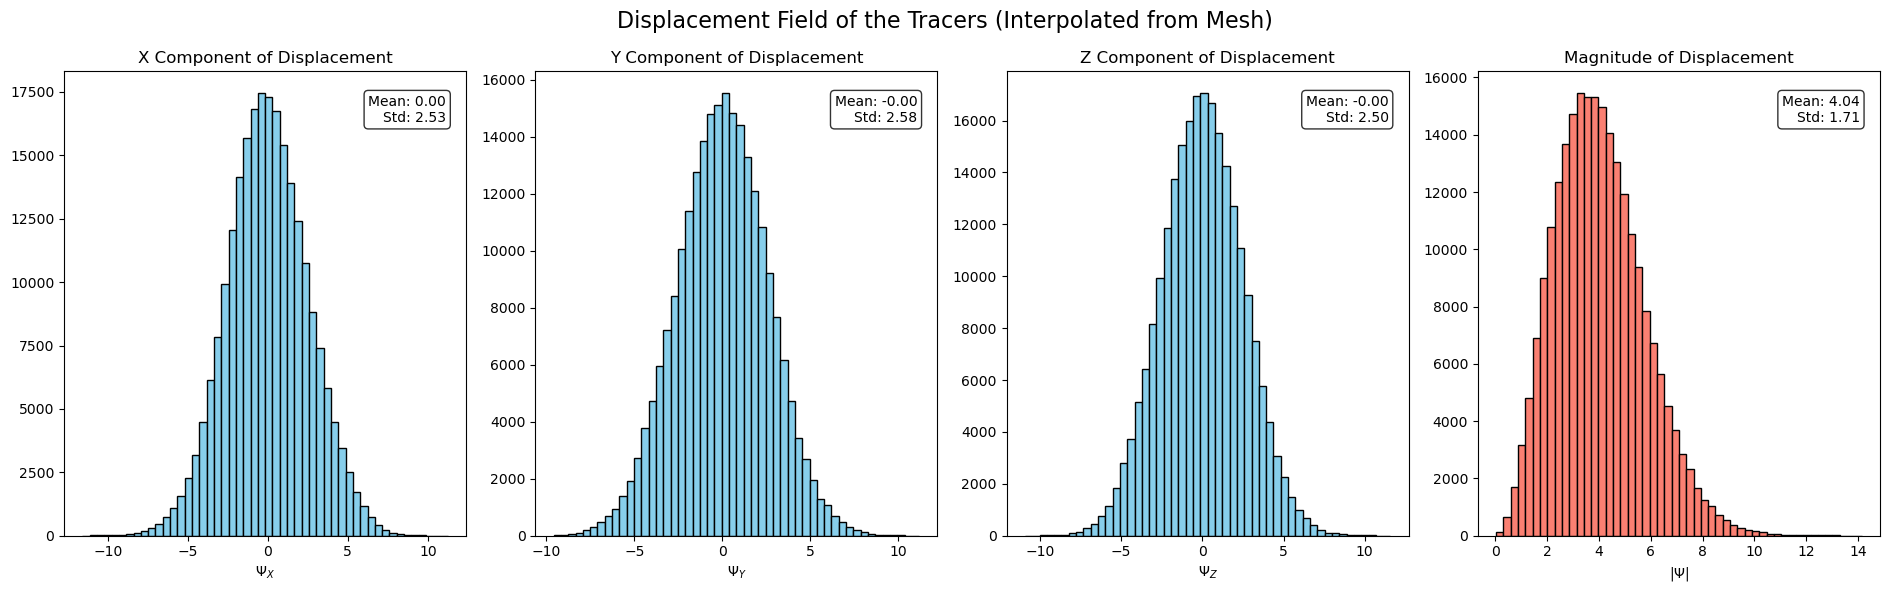

In [25]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(19, 6))

for i, comp in enumerate(['X', 'Y', 'Z']):
    axs[i].set_title(f'{comp} Component of Displacement')
    # Use index i on the last axis and flatten for the histogram
    axs[i].hist(psi_tracers_mg[..., i].flatten(), bins=50, color='skyblue', edgecolor='black')
    axs[i].set_xlabel(f'$\Psi_{comp}$')
    axs[i].text(0.95, 0.95, f'Mean: {psi_tracers_mg[..., i].mean():.2f}\nStd: {psi_tracers_mg[..., i].std():.2f}',
                transform=axs[i].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Calculate magnitude across the last axis (the 3 components)
axs[3].set_title('Magnitude of Displacement')
psi_magnitude = np.linalg.norm(psi_tracers_mg, axis=-1) 
axs[3].hist(psi_magnitude.flatten(), bins=50, color='salmon', edgecolor='black')
axs[3].set_xlabel('$|\Psi|$')
axs[3].text(0.95, 0.95, f'Mean: {psi_magnitude.mean():.2f}\nStd: {psi_magnitude.std():.2f}',
            transform=axs[3].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Displacement Field of the Tracers (Interpolated from Mesh)', fontsize=16)
plt.tight_layout()
plt.show()

Plot rec by zelda

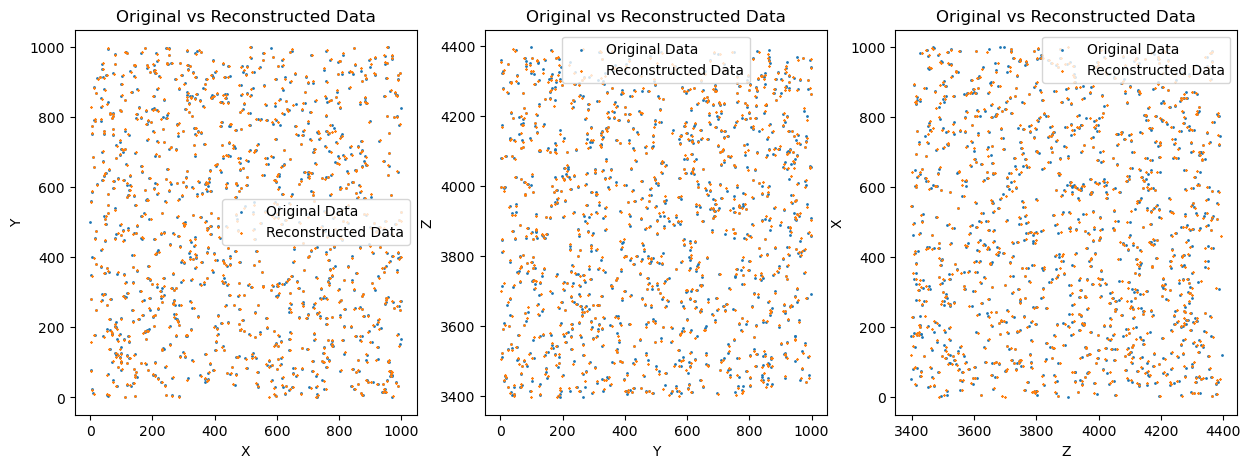

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

label = ['X', 'Y', 'Z']
for i in range(3):
    axs[i].scatter(data_pos[:1000, i], data_pos[:1000, (i+1)%3], s=1, label='Original Data')
    axs[i].scatter(data_rec[:1000, i], data_rec[:1000, (i+1)%3], s=1, marker='x', label='Reconstructed Data')
    axs[i].set_xlabel(label[i])
    axs[i].set_ylabel(label[(i+1)%3])
    axs[i].set_title('Original vs Reconstructed Data')
    axs[i].legend()

plt.savefig(f'{OUTDIR}/original_vs_reconstructed.png', dpi=300)
plt.show()

# Pyrecon 

### Density Field Construction in `pyrecon`

In the `MultiGridReconstruction` implementation, the density field $\delta(\mathbf{x})$ is built using the following sequence:

1. Grid Assignment
Data (galaxies) and Randoms are assigned to a 3D mesh (using CIC or TSC assignment) to create raw density fields $D(\mathbf{x})$ and $R(\mathbf{x})$.

2. Individual Smoothing
Both the data and random meshes are smoothed **independently** using a Gaussian kernel $S(k) = e^{-k^2 R^2 / 2}$, resulting in smoothed fields $D_s(\mathbf{x})$ and $R_s(\mathbf{x})$.

3. Density Contrast Calculation
The field is computed as the ratio of these smoothed densities to account for the survey selection function:
$$\delta(\mathbf{x}) = \frac{D_s(\mathbf{x}) / \bar{n}_d}{R_s(\mathbf{x}) / \bar{n}_r} - 1$$

4. Random Thresholding (Masking)
To prevent noise or division by zero in low-density regions, cells are masked (set to $\delta = 0$) based on the `threshold_randoms` parameter.

*   **Logic**: A cell is masked if $R_s(\mathbf{x}) < \text{Threshold}$.
*   **Default Thresholds**:
    *   **`OriginalMultigridReconstruction`**: $0.75 \times \text{mean randoms}$ (Aggressive).
    *   **`MultigridReconstruction`**: $0.01 \times \text{mean randoms}$ (Permissive).
*   **Noise-Consistent Option**: If passing `('noise', value)`, the threshold is set to:
    $$\text{Threshold} = \text{value} \times \frac{\sum w^2}{\sum w}$$

In [26]:
from pyrecon.multigrid import OriginalMultiGridReconstruction, MultiGridReconstruction
from pyrecon.iterative_fft import IterativeFFTReconstruction

note: pyrecon does not have a RSD_space setting. Instead, the behaviour depends of the growth rate:
- RedshiftSpace --> $f \neq 0$
- RealSpace --> $f = 0$

In [29]:
PYRECON_GROWTH_RATE = GROWTH_RATE if RSD_SPACE == 'redshift_space' else 0
print(f"Using growth rate f={PYRECON_GROWTH_RATE} for PyRecon based on RSD space: {RSD_SPACE}")

if COMPARE_AGAINST_PYRECON == 'iFFT':
    # --- Instantiate and configure the reconstruction solver ---
    pyrecon_MG = IterativeFFTReconstruction(
        f = PYRECON_GROWTH_RATE, 
        bias = BIAS, 
        los = LOS, 
        nmesh = NMESH,
        boxsize = recon.boxsize,        # use the same boxsize and boxcenter as the iFFT reconstruction for a fair comparison
        boxcenter = recon.boxcentre,    # use the same boxsize and boxcenter as the iFFT reconstruction for a fair comparison
        wrap = PBC, 
        resampler = MAS.lower(),
        
    )
elif COMPARE_AGAINST_PYRECON == 'MG':
    pyrecon_MG = MultiGridReconstruction(
        f = PYRECON_GROWTH_RATE, 
        bias = BIAS, 
        los = LOS, 
        nmesh = NMESH,
        boxsize = recon.boxsize,            # use the same boxsize and boxcenter as the iFFT reconstruction for a fair comparison
        boxcenter = recon.boxcentre,        # use the same boxsize and boxcenter as the iFFT reconstruction for a fair comparison
        nmeswrap = PBC, 
        resampler = MAS.lower()
    )

# --- Build density field from the reference catalogues ---
pyrecon_MG.assign_data(data_pos)
pyrecon_MG.assign_randoms(random_pos)


# --- Compute overdensity (with smoothing) and solve for displacement field ---
pyrecon_MG.set_density_contrast(smoothing_radius=SM_RAD, ran_min=RAND_TH)
pyrecon_delta = pyrecon_MG.mesh_delta.copy()

pyrecon_MG.run()

# --- Apply the solved displacement field to the requested "apply" positions ---
pos_shifted     = pyrecon_MG.read_shifted_positions(data_pos)
random_shifted  = pyrecon_MG.read_shifted_positions(random_pos)


Using growth rate f=0.88 for PyRecon based on RSD space: redshift_space


In [30]:
# get the potential field from pyrecon - note the minus sign convention in pyrecon
if COMPARE_AGAINST_PYRECON == 'iFFT':
    # pyrecon iFFT doesn't have a potential field to compare against, so we skip this step
    pass
elif COMPARE_AGAINST_PYRECON == 'MG':
    pyrecon_phi = - pyrecon_MG.mesh_phi.copy()

# Test delta and phi

Note: pyrecon internally normalizes delta with the bias, i.e. stores the matter field. ZeldaRecon instead stores the field that is passed and uses the bias when computing $\phi$ and $\psi$

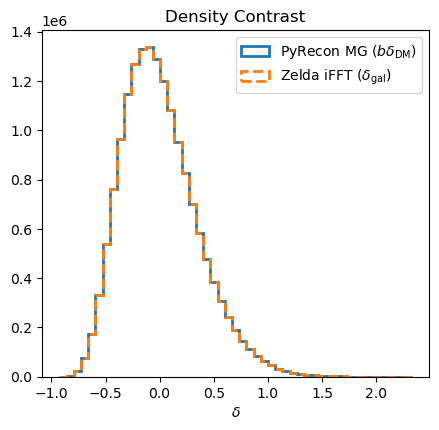

In [31]:
## test delta pdf
plt.figure(figsize=(5,4.5))
delta_bins = np.linspace(np.min([np.min(pyrecon_delta), np.min(delta_mg)]), np.max([np.max(pyrecon_delta), np.max(delta_mg)]), 50)

plt.hist(BIAS*np.array(pyrecon_delta).flatten(), bins=delta_bins, histtype='step', linewidth=2,
    label='PyRecon MG ($b\\delta_\mathrm{DM}$)')

plt.hist(delta_mg.flatten(), bins=delta_bins, histtype='step', linewidth=2, label='Zelda iFFT ($\\delta_\mathrm{gal}$)', linestyle='dashed')
plt.xlabel('$\\delta$')
plt.title('Density Contrast')
plt.legend()
plt.savefig(f'{OUTDIR}/delta_contrast_histogram.png', dpi=300)
plt.show()

Set the two potentials to have the same mean: 
- iFFT had k0 set to zero this is a null-mean field
- MG is solved by finite differences, so will have a different mean
We don't care about additive constants, so we set the mean to be the same.


In [32]:
# set the two potentials to have the same mean 
if COMPARE_AGAINST_PYRECON == 'iFFT':
    pass
elif COMPARE_AGAINST_PYRECON == 'MG':
    pyrecon_phi -= np.mean(pyrecon_phi)
    phi_mesh_ifft -= np.mean(phi_mesh_ifft)

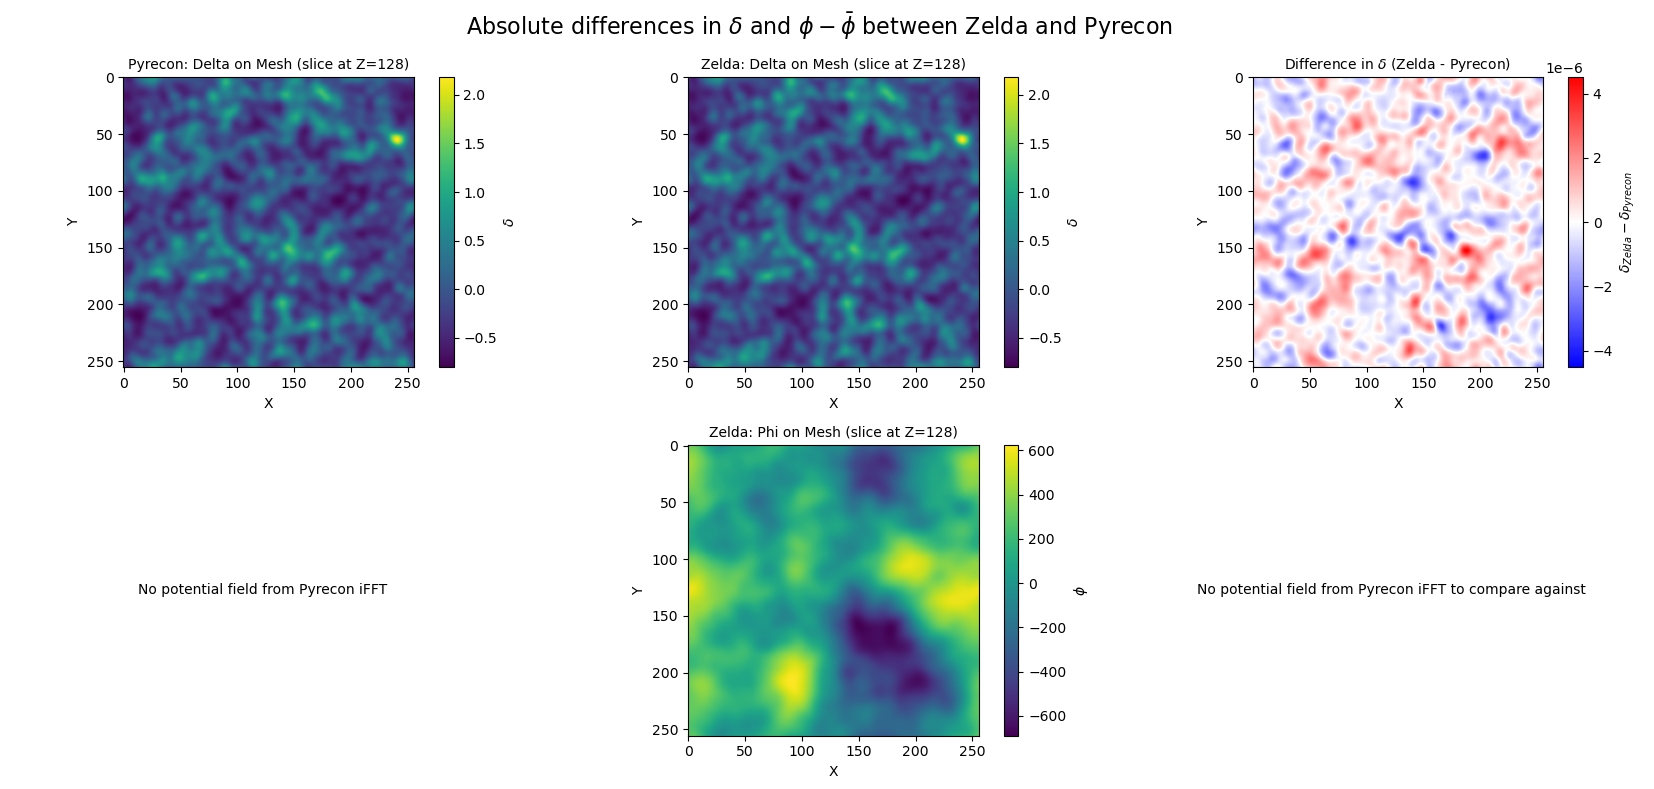

In [33]:
fig, axs = plt.subplots(2, 3, figsize=(17, 8))

# Pyrecon results
axs[0, 0].set_title('Pyrecon: Delta on Mesh (slice at Z=128)', fontsize=10)
axs[0, 0].imshow(BIAS*np.array(pyrecon_delta)[:,:,128])
axs[0, 0].set_xlabel('X')
axs[0, 0].set_ylabel('Y')
fig.colorbar(axs[0, 0].imshow(BIAS*np.array(pyrecon_delta)[:,:,128]), ax=axs[0, 0], label='$\delta$')

axs[0, 1].set_title('Zelda: Delta on Mesh (slice at Z=128)', fontsize=10)
axs[0, 1].imshow(delta_mg[:,:,128])
axs[0, 1].set_xlabel('X')
axs[0, 1].set_ylabel('Y')
fig.colorbar(axs[0, 1].imshow(delta_mg[:,:,128]), ax=axs[0, 1], label='$\delta$')

axs[0, 2].set_title('Difference in $\delta$ (Zelda - Pyrecon)', fontsize=10)
delta_diff = delta_mg - BIAS*np.array(pyrecon_delta)
im = axs[0, 2].imshow(delta_diff[:,:,128], vmin=-np.abs(delta_diff[:,:,128]).max(), vmax=np.abs(delta_diff[:,:,128]).max(), cmap='bwr')
axs[0, 2].set_xlabel('X')
axs[0, 2].set_ylabel('Y')
fig.colorbar(im, ax=axs[0, 2], label='$\delta_{Zelda} - \delta_{Pyrecon}$')

if COMPARE_AGAINST_PYRECON == 'iFFT':
    # If we're comparing against iFFT, we don't have a potential field from Pyrecon to show
    axs[1, 0].text(0.5, 0.5, 'No potential field from Pyrecon iFFT', 
                    horizontalalignment='center', verticalalignment='center', transform=axs[1, 0].transAxes)
    axs[1, 0].set_axis_off()
    axs[1, 1].set_title('Zelda: Phi on Mesh (slice at Z=128)', fontsize=10)
    axs[1, 1].imshow(phi_mesh_ifft[:,:,128])
    axs[1, 1].set_xlabel('X')
    axs[1, 1].set_ylabel('Y')
    fig.colorbar(axs[1, 1].imshow(phi_mesh_ifft[:,:,128]), ax=axs[1, 1], label='$\phi$')
elif COMPARE_AGAINST_PYRECON == 'MG':
    axs[1, 0].set_title('Pyrecon: Phi on Mesh (slice at Z=128)', fontsize=10)
    axs[1, 0].imshow(pyrecon_phi[:,:,128])
    axs[1, 0].set_xlabel('X')
    axs[1, 0].set_ylabel('Y')
    fig.colorbar(axs[1, 0].imshow(pyrecon_phi[:,:,128]), ax=axs[1, 0], label='$\phi$')

    axs[1, 1].set_title('Zelda: Phi on Mesh (slice at Z=128)', fontsize=10)
    axs[1, 1].imshow(phi_mesh_ifft[:,:,128])
    axs[1, 1].set_xlabel('X')
    axs[1, 1].set_ylabel('Y')
    fig.colorbar(axs[1, 1].imshow(phi_mesh_ifft[:,:,128]), ax=axs[1, 1], label='$\phi$')

if COMPARE_AGAINST_PYRECON == 'iFFT':
    # If we're comparing against iFFT, we don't have a potential field from Pyrecon to compare against, so we skip the difference plot
    axs[1, 2].text(0.5, 0.5, 'No potential field from Pyrecon iFFT to compare against', 
                    horizontalalignment='center', verticalalignment='center', transform=axs[1, 2].transAxes)
    axs[1, 2].set_axis_off()
elif COMPARE_AGAINST_PYRECON == 'MG':
    axs[1, 2].set_title('Difference in $\phi-\\bar{\phi}$ (Zelda - Pyrecon)', fontsize=10)
    phi_diff = phi_mesh_ifft - pyrecon_phi
    im = axs[1, 2].imshow(phi_diff[:,:,128], vmin=-np.abs(phi_diff[:,:,128]).max(), vmax=np.abs(phi_diff[:,:,128]).max(), cmap='bwr')
    axs[1, 2].set_xlabel('X')
    axs[1, 2].set_ylabel('Y')
    fig.colorbar(im, ax=axs[1, 2], label='$\phi_{Zelda} - \phi_{Pyrecon}$')

fig.suptitle('Absolute differences in $\delta$ and $\phi-\\bar{\phi}$ between Zelda and Pyrecon', fontsize=16)
plt.tight_layout()

plt.savefig(f'{OUTDIR}/delta_phi_comparison_abs.png', dpi=300)
plt.show()





Test percent differences

/tmp/ipykernel_721941/252530929.py:105: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


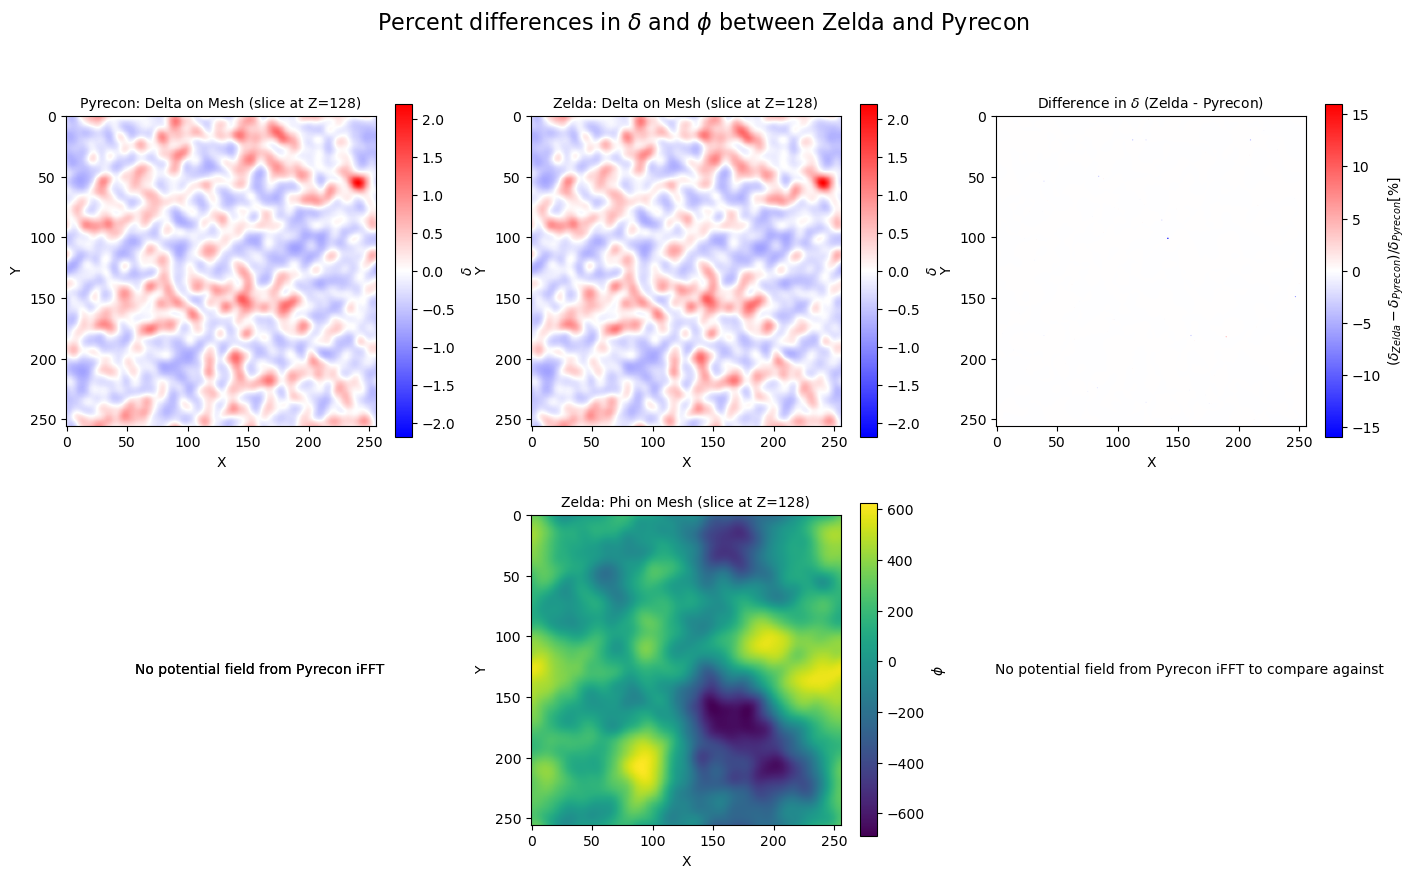

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Extract slices to make the code cleaner
z_idx = 128
pyrecon_delta_slice = BIAS*pyrecon_delta[:,:,z_idx]
delta_mg_slice = delta_mg[:,:,z_idx]

if COMPARE_AGAINST_PYRECON == 'MG':

    pyrecon_phi_slice = pyrecon_phi[:,:,z_idx]
    phi_mg_slice = phi_mesh_ifft[:,:,z_idx]

fig, axs = plt.subplots(2, 3, figsize=(17, 9.5))

# ==========================================
# ROW 0: DENSITIES (Delta)
# ==========================================

# 1. Normalize Densities (Symmetric for 'bwr' colormap so 0 is white)
delta_max_abs = max(np.abs(pyrecon_delta_slice).max(), np.abs(delta_mg_slice).max())
vmin_delta, vmax_delta = -delta_max_abs, delta_max_abs

# Pyrecon Delta
axs[0, 0].set_title(f'Pyrecon: Delta on Mesh (slice at Z={z_idx})', fontsize=10)
im_d1 = axs[0, 0].imshow(pyrecon_delta_slice, cmap='bwr', vmin=vmin_delta, vmax=vmax_delta)
axs[0, 0].set_xlabel('X')
axs[0, 0].set_ylabel('Y')
fig.colorbar(im_d1, ax=axs[0, 0], label='$\delta$')

# Zelda Delta
axs[0, 1].set_title(f'Zelda: Delta on Mesh (slice at Z={z_idx})', fontsize=10)
im_d2 = axs[0, 1].imshow(delta_mg_slice, cmap='bwr', vmin=vmin_delta, vmax=vmax_delta)
axs[0, 1].set_xlabel('X')
axs[0, 1].set_ylabel('Y')
fig.colorbar(im_d2, ax=axs[0, 1], label='$\delta$')

# Difference Delta
axs[0, 2].set_title('Difference in $\delta$ (Zelda - Pyrecon)', fontsize=10)
pyrecon_delta_div = np.where(np.abs(pyrecon_delta_slice) > 1e-5, pyrecon_delta_slice, 1e-5)
delta_diff = (delta_mg_slice - pyrecon_delta_slice) / pyrecon_delta_div * 100

diff_d_max = np.abs(delta_diff).max()
im_d3 = axs[0, 2].imshow(delta_diff, cmap='bwr', vmin=-diff_d_max, vmax=diff_d_max)
axs[0, 2].set_xlabel('X')
axs[0, 2].set_ylabel('Y')
fig.colorbar(im_d3, ax=axs[0, 2], label='$(\delta_{Zelda} - \delta_{Pyrecon})/\delta_{Pyrecon} [\\%]$')



# ==========================================
# ROW 1: POTENTIALS (Phi)
# ==========================================

# 2. Normalize Potentials (Standard min/max since standard colormap is used)
if COMPARE_AGAINST_PYRECON == 'MG':
    vmin_phi = min(pyrecon_phi_slice.min(), phi_mg_slice.min())
    vmax_phi = max(pyrecon_phi_slice.max(), phi_mg_slice.max())


    # Pyrecon Phi
    axs[1, 0].set_title(f'Pyrecon: Phi on Mesh (slice at Z={z_idx})', fontsize=10)
    im_p1 = axs[1, 0].imshow(pyrecon_phi_slice, vmin=vmin_phi, vmax=vmax_phi)
    axs[1, 0].set_xlabel('X')
    axs[1, 0].set_ylabel('Y')
    fig.colorbar(im_p1, ax=axs[1, 0], label='$\phi$')

elif COMPARE_AGAINST_PYRECON == 'iFFT':
    vmin_phi = phi_mesh_ifft[:,:,z_idx].min()
    vmax_phi = phi_mesh_ifft[:,:,z_idx].max()

    for i in [0,2]:
        axs[1, i].text(0.5, 0.5, 'No potential field from Pyrecon iFFT', 
                        horizontalalignment='center', verticalalignment='center', transform=axs[1, 0].transAxes)
        axs[1, i].set_axis_off()

# Zelda Phi
axs[1, 1].set_title(f'Zelda: Phi on Mesh (slice at Z={z_idx})', fontsize=10)
if COMPARE_AGAINST_PYRECON == 'MG':
    im_p2 = axs[1, 1].imshow(phi_mg_slice, vmin=vmin_phi, vmax=vmax_phi)
else:
    im_p2 = axs[1, 1].imshow(phi_mesh_ifft[:, :, z_idx], vmin=vmin_phi, vmax=vmax_phi)
axs[1, 1].set_xlabel('X')
axs[1, 1].set_ylabel('Y')
fig.colorbar(im_p2, ax=axs[1, 1], label='$\phi$')

# Difference Phi
if COMPARE_AGAINST_PYRECON == 'iFFT':
    axs[1, 2].text(0.5, 0.5, 'No potential field from Pyrecon iFFT to compare against', 
                    horizontalalignment='center', verticalalignment='center', transform=axs[1, 2].transAxes)
    axs[1, 2].set_axis_off()
    
elif COMPARE_AGAINST_PYRECON == 'MG':
    axs[1, 2].set_title('Difference in $\phi$ (Zelda - Pyrecon)', fontsize=10)
    pyrecon_phi_div = np.where(np.abs(pyrecon_phi_slice) > 1e-5, pyrecon_phi_slice, 1e-5)
    phi_diff = (phi_mg_slice - pyrecon_phi_slice) / pyrecon_phi_div * 100

    diff_p_max = np.abs(phi_diff).max()
    im_p3 = axs[1, 2].imshow(phi_diff, cmap='bwr', vmin=-diff_p_max, vmax=diff_p_max)
    axs[1, 2].set_xlabel('X')
    axs[1, 2].set_ylabel('Y')
    fig.colorbar(im_p3, ax=axs[1, 2], label='$(\phi_{Zelda} - \phi_{Pyrecon})/\phi_{Pyrecon} [\\%]$')

plt.suptitle('Percent differences in $\delta$ and $\phi$ between Zelda and Pyrecon', fontsize=16)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/delta_phi_comparison_percent.png', dpi=300)
plt.show()

In [36]:
def where_percent_diff_exceeds(arr1, arr2, threshold=10):
    with np.errstate(divide='ignore', invalid='ignore'):
        percent_diff = np.abs(arr1 - arr2) / np.where(np.abs(arr2) > 1e-16, np.abs(arr2), 1e-16) * 100
    return np.where(percent_diff > threshold)

In [38]:
import yaml
import os

# Calcolo delle frazioni
frac_diff_delta = len(where_percent_diff_exceeds(delta_mg, BIAS*np.array(pyrecon_delta), threshold=0.1)) / delta_mg.size * 100
print(f"fraction of points with >0.1% diff in delta: {frac_diff_delta:.4f} %")

if COMPARE_AGAINST_PYRECON == 'MG':
      frac_diff_phi = len(where_percent_diff_exceeds(phi_mesh_mg, pyrecon_phi, threshold=0.1)) / phi_mesh_mg.size * 100
      print(f"fraction of points with >0.1% diff in phi: {frac_diff_phi:.4f} %")
else:
      frac_diff_phi = None

# Assicuriamoci che 'results' esista (nel caso questa cella venga eseguita da sola)
if 'results' not in locals():
    results = {}

# Creiamo il sottomenù per le differenze percentuali
results['percent_diff'] = {
    'delta_exceeds_0.1': float(frac_diff_delta),
    'phi_exceeds_0.1': float(frac_diff_phi) if frac_diff_phi is not None else 'N/A'
}

# Salviamo l'intero dizionario aggiornato nel file YAML
os.makedirs(OUTDIR, exist_ok=True)
with open(os.path.join(OUTDIR, "results.yaml"), "w") as f:
    yaml.dump(results, f)

fraction of points with >0.1% diff in delta: 0.0000 %


## Test displacements

#### mesh

In [39]:
pyrecon_psi_mesh = pyrecon_MG.mesh_psi.copy()
pyrecon_psi_mesh = np.array(pyrecon_psi_mesh).T
print(pyrecon_psi_mesh.shape)

(256, 256, 256, 3)


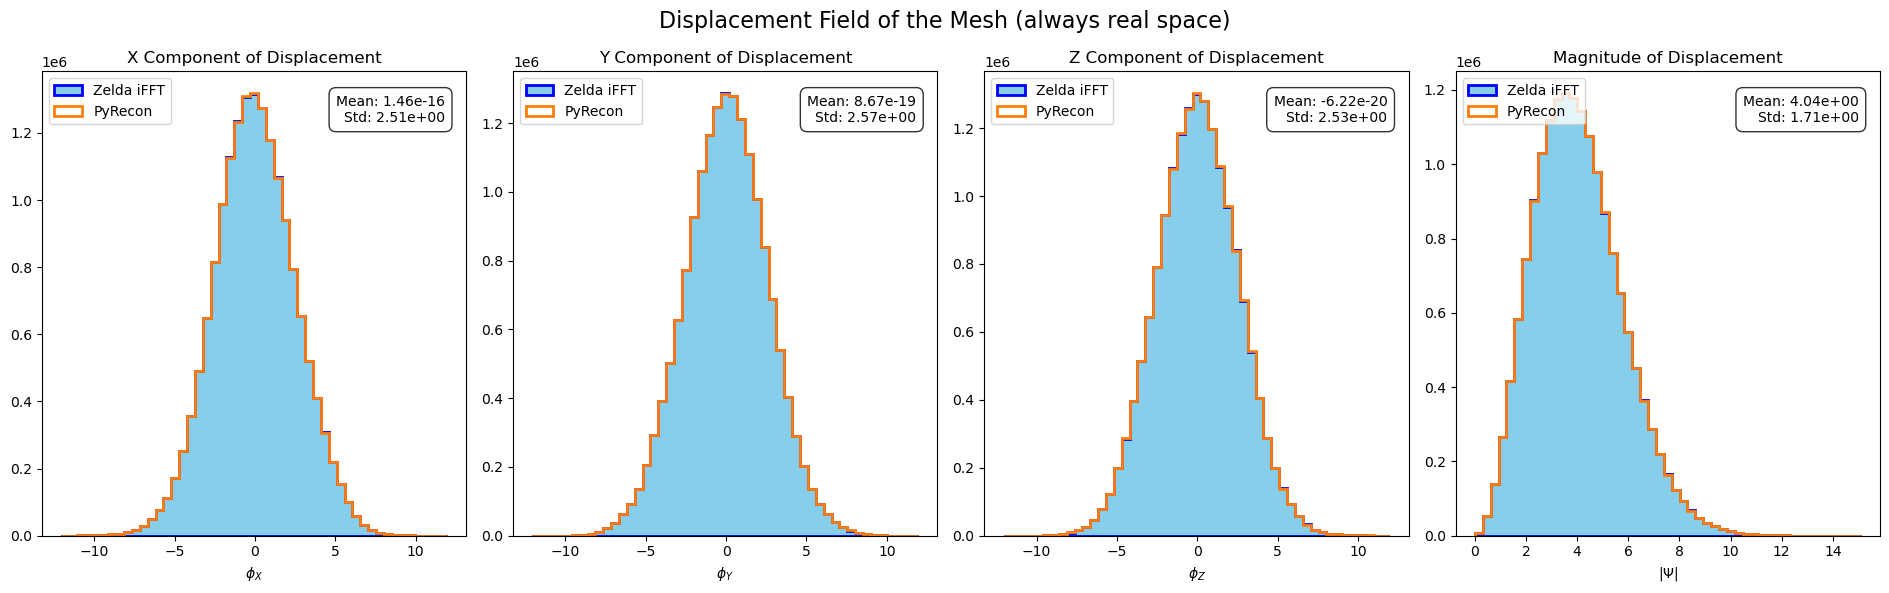

In [41]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(19, 6))

bin_edges = np.linspace(np.min([psi_mesh_ifft.min(), pyrecon_psi_mesh.min()]), np.max([psi_mesh_ifft.max(), pyrecon_psi_mesh.max()]), 50)
mag_edges = np.linspace(0, max(np.linalg.norm(psi_mesh_ifft, axis=-1).max(), np.linalg.norm(pyrecon_psi_mesh, axis=-1).max()), 50)

for i, comp in enumerate(['X', 'Y', 'Z']):
    axs[i].set_title(f'{comp} Component of Displacement')
    # Use index i on the last axis and flatten for the histogram
    axs[i].hist(psi_mesh_ifft[..., i].flatten(), bins=bin_edges, color='skyblue', edgecolor='blue', histtype='stepfilled', linewidth = 2, label='Zelda iFFT')
    axs[i].hist(pyrecon_psi_mesh[..., i].flatten(), bins=bin_edges, color='tab:orange', edgecolor='tab:orange', histtype='step', linewidth=2, label='PyRecon')
    axs[i].set_xlabel(f'$\\phi_{comp}$')
    axs[i].text(0.95, 0.95, f'Mean: {psi_mesh_ifft[..., i].mean():.2e}\nStd: {psi_mesh_ifft[..., i].std():.2e}',
            transform=axs[i].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
    axs[i].legend(loc='upper left')


# Calculate magnitude across the last axis (the 3 components)
axs[3].set_title('Magnitude of Displacement')
psi_magnitude = np.linalg.norm(psi_mesh_ifft, axis=-1) 
psi_magnitude_pyrecon = np.linalg.norm(pyrecon_psi_mesh, axis=-1)
axs[3].hist(psi_magnitude.flatten(), bins=mag_edges, color='skyblue', edgecolor='blue', histtype='stepfilled', linewidth = 2, label='Zelda iFFT')
axs[3].hist(psi_magnitude_pyrecon.flatten(), bins=mag_edges, color='tab:orange', edgecolor='tab:orange', histtype='step', linewidth = 2, label='PyRecon')
axs[3].set_xlabel('$|\Psi|$')
axs[3].text(0.95, 0.95, f'Mean: {psi_magnitude.mean():.2e}\nStd: {psi_magnitude.std():.2e}',
            transform=axs[3].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
axs[3].legend(loc='upper left')

plt.suptitle('Displacement Field of the Mesh (always real space)', fontsize=16)


plt.tight_layout()
plt.savefig(f'{OUTDIR}/displacement_mesh_histograms.png', dpi=300)
plt.show()

### tracers

rsd component

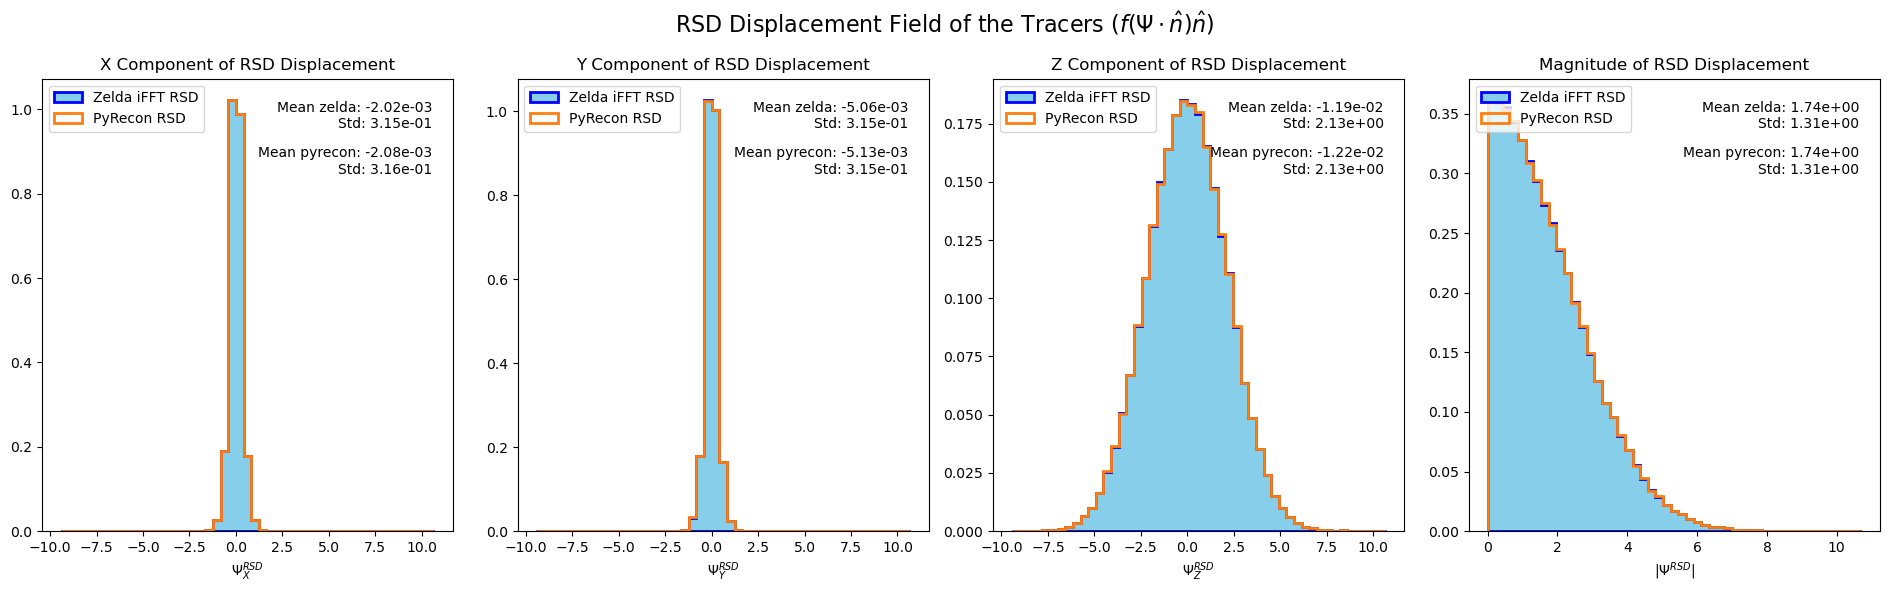

In [42]:
# debugging of rsd displacements

pyrecon_psi_rsd = pyrecon_MG.read_shifts(positions=data_pos, field='rsd')

# disp = only real space psi
# rsd = rsd disp
# disp+rsd = full redshift space displacement

#1 interp psi from mesh to tracers
t_psi_tracers_mg = recon._interpolate_displacement(recon.data_pos)
#2 compute rsd displacements from the interpolated real space displacements
t_psi_tracers_mg_rsd = recon._get_rsd_displacement(t_psi_tracers_mg, recon.data_pos)
#3 compare to pyrecon rsd displacements
fig, axs = plt.subplots(1, 4, figsize=(19, 6))

bin_edges = np.linspace(np.min([t_psi_tracers_mg_rsd.min(), pyrecon_psi_rsd.min()]), np.max([t_psi_tracers_mg_rsd.max(), pyrecon_psi_rsd.max()]), 50)
mag_edges = np.linspace(0, max(np.linalg.norm(t_psi_tracers_mg_rsd, axis=-1).max(), np.linalg.norm(pyrecon_psi_rsd, axis=-1).max()), 50)


for i, comp in enumerate(['X', 'Y', 'Z']):
    axs[i].set_title(f'{comp} Component of RSD Displacement')
    # Use index i on the last axis and flatten for the histogram
    axs[i].hist(t_psi_tracers_mg_rsd[..., i].flatten(), bins=bin_edges, color='skyblue', edgecolor='blue', histtype='stepfilled', 
        linewidth = 2, label='Zelda iFFT RSD', density=True)
    axs[i].hist(pyrecon_psi_rsd[..., i].flatten(), bins=bin_edges, color='tab:orange', edgecolor='tab:orange', histtype='step', 
        linewidth = 2, label='PyRecon RSD', density=True)
    axs[i].set_xlabel(f'$\Psi_{{{comp}}}^{{RSD}}$')
    axs[i].text(0.95, 0.95, f'Mean zelda: {t_psi_tracers_mg_rsd[..., i].mean():.2e}\nStd: {t_psi_tracers_mg_rsd[..., i].std():.2e}', 
        transform=axs[i].transAxes, verticalalignment='top', horizontalalignment='right')    
    axs[i].text(0.95, 0.85, f'Mean pyrecon: {pyrecon_psi_rsd[..., i].mean():.2e}\nStd: {pyrecon_psi_rsd[..., i].std():.2e}', 
        transform=axs[i].transAxes, verticalalignment='top', horizontalalignment='right')
    axs[i].legend(loc='upper left')

# Calculate magnitude across the last axis (the 3 components)
axs[3].set_title('Magnitude of RSD Displacement')
t_psi_magnitude_rsd = np.linalg.norm(t_psi_tracers_mg_rsd, axis=-1) 
pyrecon_psi_magnitude_rsd = np.linalg.norm(pyrecon_psi_rsd, axis=-1)
axs[3].hist(t_psi_magnitude_rsd.flatten(), bins=mag_edges, color='skyblue', edgecolor='blue', histtype='stepfilled', 
    
linewidth = 2, label='Zelda iFFT RSD', density=True)
axs[3].hist(pyrecon_psi_magnitude_rsd.flatten(), bins=mag_edges, color='tab:orange', edgecolor='tab:orange', histtype='step', 
    linewidth = 2, label='PyRecon RSD', density=True)
axs[3].set_xlabel('$|\Psi^{RSD}|$')
axs[3].text(0.95, 0.95, f'Mean zelda: {t_psi_magnitude_rsd.mean():.2e}\nStd: {t_psi_magnitude_rsd.std():.2e}', 
    
transform=axs[3].transAxes, verticalalignment='top', horizontalalignment='right')    
axs[3].text(0.95, 0.85, f'Mean pyrecon: {pyrecon_psi_magnitude_rsd.mean():.2e}\nStd: {pyrecon_psi_magnitude_rsd.std():.2e}', 
    transform=axs[3].transAxes, verticalalignment='top', horizontalalignment='right')
axs[3].legend(loc='upper left')
plt.suptitle('RSD Displacement Field of the Tracers ($f(\Psi\cdot\hat{n})\hat{n}$)', fontsize=16)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/displacement_rsd_histograms.png', dpi=300)
plt.show()

In [43]:
compute_and_save_ks(t_psi_tracers_mg_rsd, pyrecon_psi_rsd, t_psi_magnitude_rsd, pyrecon_psi_magnitude_rsd, results, OUTDIR, key_name='ks_psi_rsd')

--- KS test results for: ks_psi_rsd ---
  X: statistic=0.0004, p-value=1.0000e+00
  Y: statistic=0.0005, p-value=1.0000e+00
  Z: statistic=0.0005, p-value=1.0000e+00
  Magnitude: statistic=0.0008, p-value=1.0000e+00



{'percent_diff': {'delta_exceeds_0.1': 1.7881393432617188e-05,
  'phi_exceeds_0.1': 'N/A'},
 'ks_psi_rsd': {'ks_X': 0.0004365364193100185,
  'ks_X_pvalue': 1.0,
  'ks_Y': 0.00046172121273174715,
  'ks_Y_pvalue': 1.0,
  'ks_Z': 0.0005120907995752044,
  'ks_Z_pvalue': 0.9999999999999999,
  'ks_magnitude': 0.0007681361993628899,
  'ks_magnitude_pvalue': 0.9999997604912313}}

real space component

In [44]:
# displacement in real space

pyrecon_psi = pyrecon_MG.read_shifts(positions=data_pos, field='disp')

# disp = only real space psi
# rsd = rsd disp
# disp+rsd = full redshift space displacement

psi_tracers_mg = recon._interpolate_displacement(recon.data_pos)

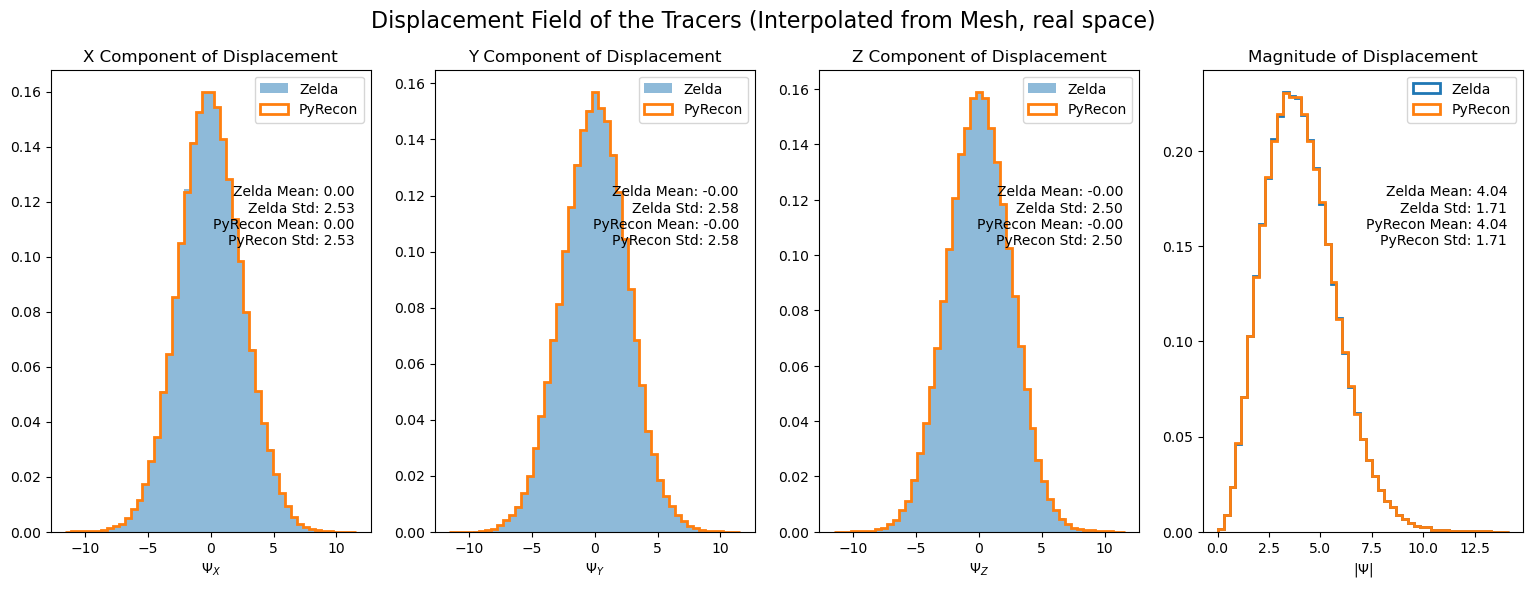

In [47]:
fig, axs = plt.subplots(1, 4, figsize=(19, 6))

bin_edges = np.linspace(np.min([psi_tracers_mg.min(), pyrecon_psi.min()]), np.max([psi_tracers_mg.max(), pyrecon_psi.max()]), 50)
mag_edges = np.linspace(0, max(np.linalg.norm(psi_tracers_mg, axis=1).max(), np.linalg.norm(pyrecon_psi, axis=1).max()), 50)


for i, comp in enumerate(['X', 'Y', 'Z']):
    axs[i].set_title(f'{comp} Component of Displacement')
    axs[i].hist(psi_tracers_mg[:,i], bins=bin_edges, alpha=0.5, label='Zelda', density=True)
    axs[i].hist(pyrecon_psi[:,i], bins=bin_edges, label='PyRecon', histtype='step', linewidth = 2, density=True)
    axs[i].set_xlabel(f'$\Psi_{{{comp}}}$')
    axs[i].text(0.95, 0.75, f'Zelda Mean: {psi_tracers_mg[:,i].mean():.2f}\nZelda Std: {psi_tracers_mg[:,i].std():.2f}\nPyRecon Mean: {pyrecon_psi[:,i].mean():.2f}\nPyRecon Std: {pyrecon_psi[:,i].std():.2f}', 
        transform=axs[i].transAxes, verticalalignment='top', horizontalalignment='right')

axs[3].set_title('Magnitude of Displacement')
psi_magnitude = np.linalg.norm(pyrecon_psi, axis=1)
psi_magnitude_zelda = np.linalg.norm(psi_tracers_mg, axis=1)

axs[3].hist(psi_magnitude_zelda, bins=mag_edges, label='Zelda', histtype='step', linewidth = 2, density=True)
axs[3].hist(psi_magnitude, bins=mag_edges, label='PyRecon', histtype='step', linewidth = 2, density=True)

axs[3].text(0.95, 0.75, f'Zelda Mean: {psi_magnitude_zelda.mean():.2f}\nZelda Std: {psi_magnitude_zelda.std():.2f}\nPyRecon Mean: {psi_magnitude.mean():.2f}\nPyRecon Std: {psi_magnitude.std():.2f}', 
    transform=axs[3].transAxes, verticalalignment='top', horizontalalignment='right')

axs[3].set_xlabel('$|\Psi|$') 
fig.suptitle('Displacement Field of the Tracers (Interpolated from Mesh, real space)', fontsize=16)
for ax in axs:
    ax.legend()
plt.savefig(f'{OUTDIR}/displacement_tracers_histograms.png', dpi=300)

In [48]:
compute_and_save_ks(psi_tracers_mg, pyrecon_psi, psi_magnitude_zelda, psi_magnitude, results, OUTDIR, key_name='ks_psi_realspace')

--- KS test results for: ks_psi_realspace ---
  X: statistic=0.0006, p-value=1.0000e+00
  Y: statistic=0.0004, p-value=1.0000e+00
  Z: statistic=0.0004, p-value=1.0000e+00
  Magnitude: statistic=0.0005, p-value=1.0000e+00



{'percent_diff': {'delta_exceeds_0.1': 1.7881393432617188e-05,
  'phi_exceeds_0.1': 'N/A'},
 'ks_psi_rsd': {'ks_X': 0.0004365364193100185,
  'ks_X_pvalue': 1.0,
  'ks_Y': 0.00046172121273174715,
  'ks_Y_pvalue': 1.0,
  'ks_Z': 0.0005120907995752044,
  'ks_Z_pvalue': 0.9999999999999999,
  'ks_magnitude': 0.0007681361993628899,
  'ks_magnitude_pvalue': 0.9999997604912313},
 'ks_psi_realspace': {'ks_X': 0.0005792502486998696,
  'ks_X_pvalue': 0.9999999999994298,
  'ks_Y': 0.00043653641931007403,
  'ks_Y_pvalue': 1.0,
  'ks_Z': 0.0004323389537397304,
  'ks_Z_pvalue': 1.0,
  'ks_magnitude': 0.0004827085405832987,
  'ks_magnitude_pvalue': 1.0}}

real space psi + rsd component

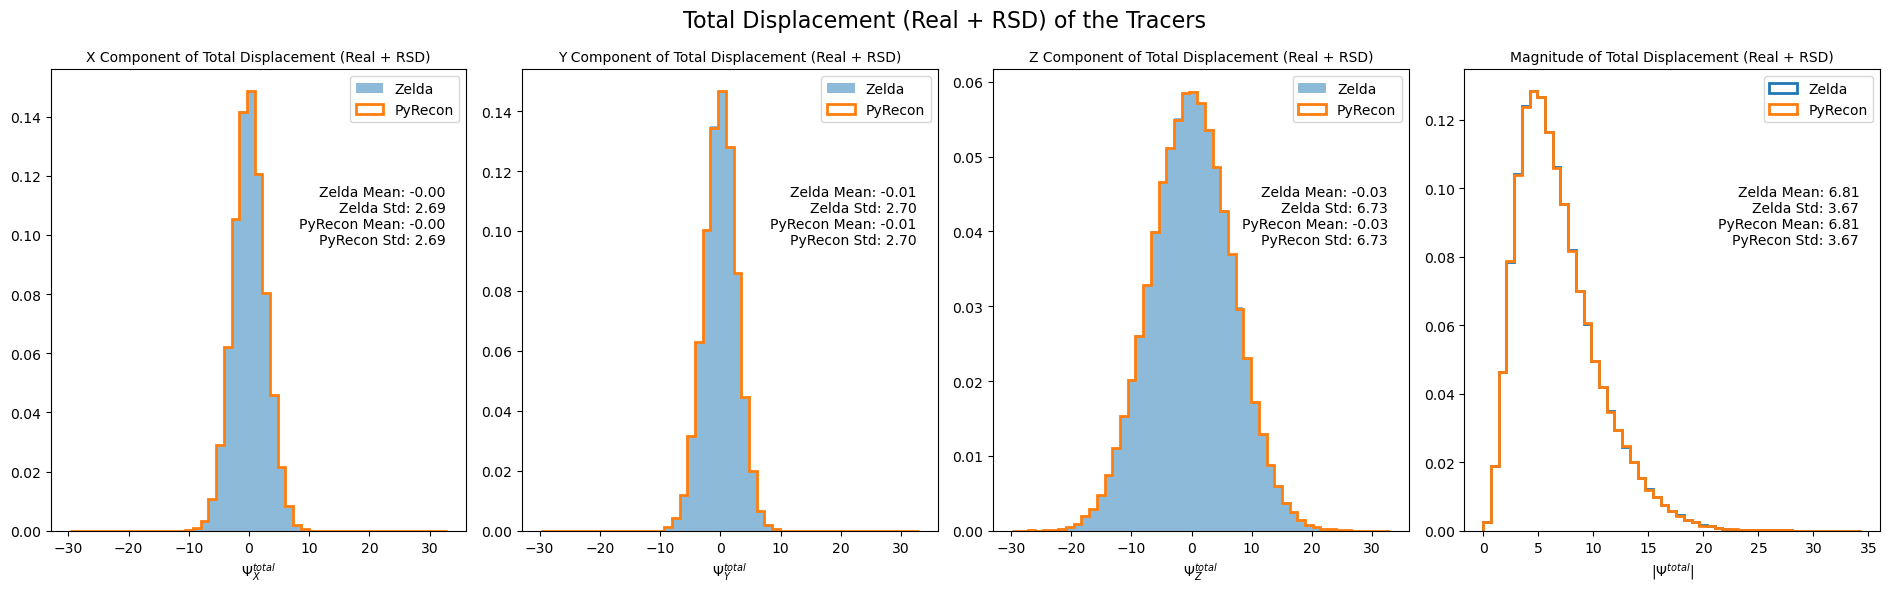

In [51]:
psi_tracers_mg += t_psi_tracers_mg_rsd
pyrecon_psi += pyrecon_psi_rsd
fig, axs = plt.subplots(1, 4, figsize=(19, 6))

bin_edges = np.linspace(np.min([psi_tracers_mg.min(), pyrecon_psi.min()]), np.max([psi_tracers_mg.max(), pyrecon_psi.max()]), 50)
mag_edges = np.linspace(0, max(np.linalg.norm(psi_tracers_mg, axis=1).max(), np.linalg.norm(pyrecon_psi, axis=1).max()), 50)

for i, comp in enumerate(['X', 'Y', 'Z']):
    axs[i].set_title(f'{comp} Component of Total Displacement (Real + RSD)', fontsize=10)
    axs[i].hist(psi_tracers_mg[:,i], bins=bin_edges, alpha=0.5, label='Zelda', density=True)
    axs[i].hist(pyrecon_psi[:,i], bins=bin_edges, label='PyRecon', histtype='step', linewidth = 2, density=True)
    axs[i].set_xlabel(f'$\Psi_{{{comp}}}^{{total}}$')
    axs[i].text(0.95, 0.75, f'Zelda Mean: {psi_tracers_mg[:,i].mean():.2f}\nZelda Std: {psi_tracers_mg[:,i].std():.2f}\nPyRecon Mean: {pyrecon_psi[:,i].mean():.2f}\nPyRecon Std: {pyrecon_psi[:,i].std():.2f}',
        transform=axs[i].transAxes, verticalalignment='top', horizontalalignment='right')

axs[3].set_title('Magnitude of Total Displacement (Real + RSD)', fontsize=10)
psi_magnitude_total_zelda = np.linalg.norm(psi_tracers_mg, axis=1)
psi_magnitude_total_pyrecon = np.linalg.norm(pyrecon_psi, axis=1)   
axs[3].hist(psi_magnitude_total_zelda, bins=mag_edges, label='Zelda', histtype='step', linewidth = 2, density=True)
axs[3].hist(psi_magnitude_total_pyrecon, bins=mag_edges, label='PyRecon', histtype='step', linewidth = 2, density=True)
axs[3].text(0.95, 0.75, f'Zelda Mean: {psi_magnitude_total_zelda.mean():.2f}\nZelda Std: {psi_magnitude_total_zelda.std():.2f}\nPyRecon Mean: {psi_magnitude_total_pyrecon.mean():.2f}\nPyRecon Std: {psi_magnitude_total_pyrecon.std():.2f}',
    transform=axs[3].transAxes, verticalalignment='top', horizontalalignment='right')
axs[3].set_xlabel('$|\Psi^{total}|$')

fig.suptitle('Total Displacement (Real + RSD) of the Tracers', fontsize=16)

for ax in axs:
    ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTDIR}/displacement_total_histograms.png', dpi=300)
plt.show()

In [52]:
compute_and_save_ks(psi_tracers_mg, pyrecon_psi, psi_magnitude_total_zelda, 
    psi_magnitude_total_pyrecon, results_dict=results, key_name='ks_psi_tot', outdir=OUTDIR)

--- KS test results for: ks_psi_tot ---
  X: statistic=0.0005, p-value=1.0000e+00
  Y: statistic=0.0006, p-value=1.0000e+00
  Z: statistic=0.0006, p-value=1.0000e+00
  Magnitude: statistic=0.0006, p-value=1.0000e+00



{'percent_diff': {'delta_exceeds_0.1': 1.7881393432617188e-05,
  'phi_exceeds_0.1': 'N/A'},
 'ks_psi_rsd': {'ks_X': 0.0004365364193100185,
  'ks_X_pvalue': 1.0,
  'ks_Y': 0.00046172121273174715,
  'ks_Y_pvalue': 1.0,
  'ks_Z': 0.0005120907995752044,
  'ks_Z_pvalue': 0.9999999999999999,
  'ks_magnitude': 0.0007681361993628899,
  'ks_magnitude_pvalue': 0.9999997604912313},
 'ks_psi_realspace': {'ks_X': 0.0005792502486998696,
  'ks_X_pvalue': 0.9999999999994298,
  'ks_Y': 0.00043653641931007403,
  'ks_Y_pvalue': 1.0,
  'ks_Z': 0.0004323389537397304,
  'ks_Z_pvalue': 1.0,
  'ks_magnitude': 0.0004827085405832987,
  'ks_magnitude_pvalue': 1.0},
 'ks_psi_tot': {'ks_X': 0.0005078933340049302,
  'ks_X_pvalue': 0.9999999999999999,
  'ks_Y': 0.0006128299732621745,
  'ks_Y_pvalue': 0.999999999985859,
  'ks_Z': 0.0005624603864186895,
  'ks_Z_pvalue': 0.9999999999999083,
  'ks_magnitude': 0.0006212249044027507,
  'ks_magnitude_pvalue': 0.9999999999708977}}

In [53]:
#test displacement difference by object
displacement_diff = psi_tracers_mg - pyrecon_psi
displacement_diff_magnitude = np.linalg.norm(displacement_diff, axis=1)

print(f'Mean displacement difference magnitude: {displacement_diff_magnitude.mean():.4f} Mpc/h')

Mean displacement difference magnitude: 0.0735 Mpc/h


In [55]:
# Define a slice thickness for the Z-axis to avoid projecting the whole box
# Change depth_limit to recon.boxsize if you truly want the full projection
depth_limit = 50
xy_limit = 150

def get_slice_mask(data):
    """Returns a mask for a 3D sub-volume (corner slice), excluding padding zones."""
    # Il volume con dati validi va da PAD a (recon.boxsize - PAD)
    x_max = min(PAD + xy_limit, recon.boxsize - PAD)
    y_max = min(PAD + xy_limit, recon.boxsize - PAD)
    z_max = min(PAD + depth_limit, recon.boxsize - PAD)
    
    return (data[:, 0] > PAD) & (data[:, 0] < x_max) & \
           (data[:, 1] > PAD) & (data[:, 1] < y_max) & \
           (data[:, 2] > PAD) & (data[:, 2] < z_max)

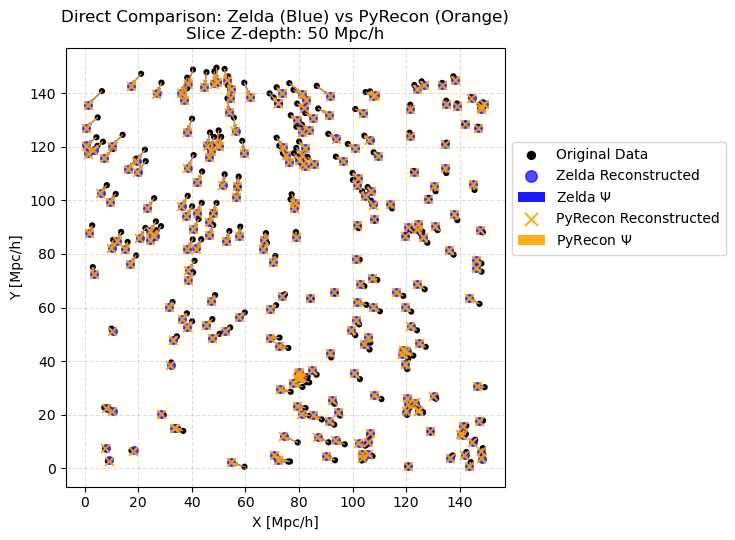

In [56]:
# 1. Creazione della maschera di intersezione totale
# Include solo i punti che rimangono nella slice in tutti e tre gli stati:
# Originale, Ricostruito Zelda e Ricostruito PyRecon

from zeldareco.utils.formatters import survey_to_box_frame

min_corner = recon._density_manager.min_corner

data_pos_box    = survey_to_box_frame(data_pos, min_corner=min_corner, boxsize=recon.boxsize,pbc=PBC)
data_rec_box    = survey_to_box_frame(data_rec, min_corner=min_corner, boxsize=recon.boxsize,pbc=PBC)
pos_shifted_box = survey_to_box_frame(pos_shifted, min_corner=min_corner, boxsize=recon.boxsize,pbc=PBC)

mask_all = get_slice_mask(data_pos_box) & \
           get_slice_mask(data_rec_box) & \
           get_slice_mask(pos_shifted_box)

plt.figure(figsize=(7, 5.5))

# --- DATA ORIGINALE (NERO) ---
plt.scatter(data_pos_box[mask_all, 0], data_pos_box[mask_all, 1], 
            s=20, label='Original Data', color='black', edgecolors='none')

# --- ZELDA RECON (BLU) ---
# Punti ricostruiti
plt.scatter(data_rec_box[mask_all, 0], data_rec_box[mask_all, 1], 
            s=30, alpha=0.7, label='Zelda Reconstructed', color='blue', marker='o')

# Vettori spostamento (più larghi per fare da sfondo)
plt.quiver(data_pos_box[mask_all, 0], data_pos_box[mask_all, 1], 
           -psi_tracers_mg[mask_all, 0], -psi_tracers_mg[mask_all, 1], 
           angles='xy', scale_units='xy', scale=1.0,
           color='blue', width=0.003,  alpha=0.9, label='Zelda $\Psi$')

# --- PYRECON (ARANCIONE) ---
# Punti ricostruiti (marker 'x')
plt.scatter(pos_shifted_box[mask_all, 0], pos_shifted_box[mask_all, 1],
            s=40, alpha=0.9, label='PyRecon Reconstructed', color='orange', marker='x')

# Vettori spostamento
plt.quiver(data_pos_box[mask_all, 0], data_pos_box[mask_all, 1], 
           -pyrecon_psi[mask_all, 0], -pyrecon_psi[mask_all, 1], 
           angles='xy', scale_units='xy', scale=1.0,
           color='orange', width=0.003,  alpha=0.9, label='PyRecon $\Psi$')

# --- FORMATTAZIONE ---
plt.xlabel('X [Mpc/h]')
plt.ylabel('Y [Mpc/h]')
plt.title(f'Direct Comparison: Zelda (Blue) vs PyRecon (Orange)\nSlice Z-depth: {depth_limit} Mpc/h')
plt.gca().set_aspect('equal')
plt.grid(True, linestyle='--', alpha=0.4)

plt.legend(bbox_to_anchor=(1.52, 0.8), loc='upper right', markerscale=1.5, ncols=1)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/displacement_and_pos_comparison_slice.png', dpi=300)
plt.show()

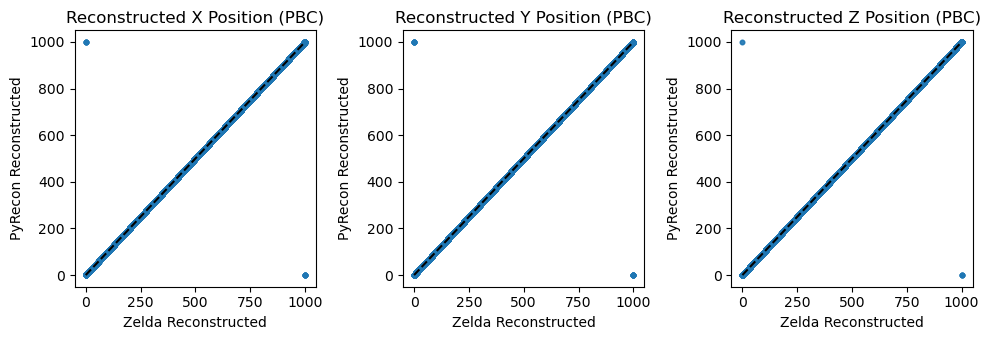

In [57]:
#check rec pos zelda vs pyrecon
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
labels = ['X', 'Y', 'Z']

if PBC:

    for i in range(3):
        axs[i].set_title(f'Reconstructed {labels[i]} Position (PBC)')
        axs[i].scatter(data_rec_box[:, i], pos_shifted_box[:, i], 
            s=10, alpha=0.7, label='Reconstructed Positions', color='tab:blue')
        axs[i].plot([0, recon.boxsize], [0, recon.boxsize], 'k--')
        axs[i].set_xlabel('Zelda Reconstructed')
        axs[i].set_ylabel('PyRecon Reconstructed')

else:
    for i in range(3):
        axs[i].set_title(f'Reconstructed {labels[i]} Position ')
        axs[i].scatter(data_rec[:, i], pos_shifted[:, i], 
            s=10, alpha=0.7, label='Reconstructed Positions', color='tab:blue')
        axs[i].plot([data_rec[:, i].min(), data_rec[:, i].max()],
            [data_rec[:, i].min(), data_rec[:, i].max()],
            'k--')
        axs[i].set_xlabel('Zelda Reconstructed')
        axs[i].set_ylabel('PyRecon Reconstructed')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/rec_pos_comparison_scatter.png', dpi=300)
plt.show()
